In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from hydra.utils import instantiate
from omegaconf import OmegaConf


In [2]:
REPO = Path("/scratch2/ij292/tnp-crps")
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "external/tnp"))

cfg = OmegaConf.load(REPO / "experiments/configs/generators/sawtooth_1d_interpolation_nc128.yml")
OmegaConf.resolve(cfg)

In [3]:
gen = instantiate(cfg.generators.train)
batch = next(iter(gen))

print("xc shape:", tuple(batch.xc.shape))
print("yc shape:", tuple(batch.yc.shape))
print(
    "Context x-range:",
    float(batch.xc.min()),
    float(batch.xc.max()),
)

assert batch.xc.shape[1] == 128, (
    f"Expected Nc=128, got Nc={batch.xc.shape[1]}"
)


xc shape: (16, 128, 1)
yc shape: (16, 128, 1)
Context x-range: -1.9981062412261963 1.9995484352111816


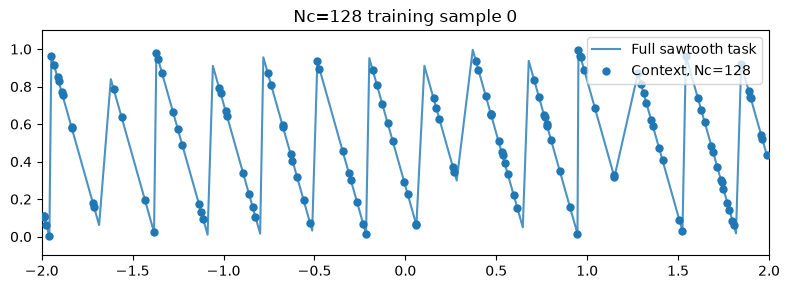

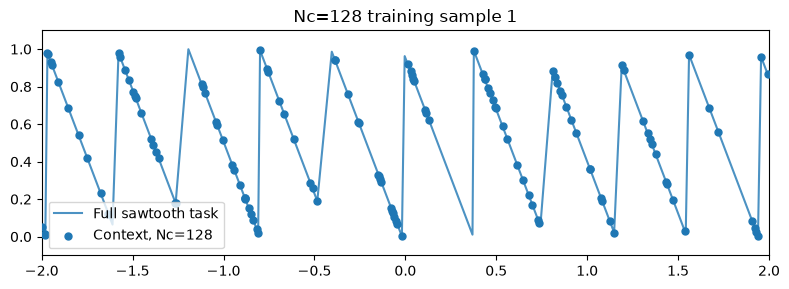

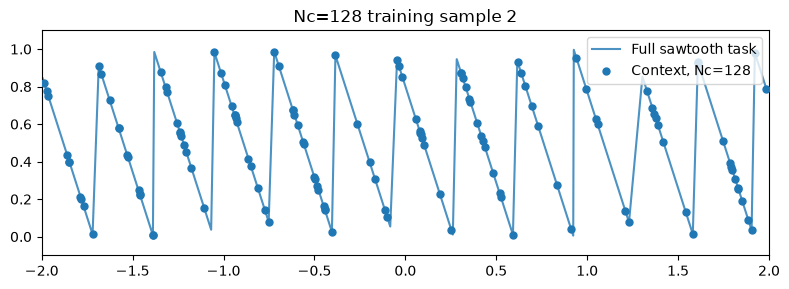

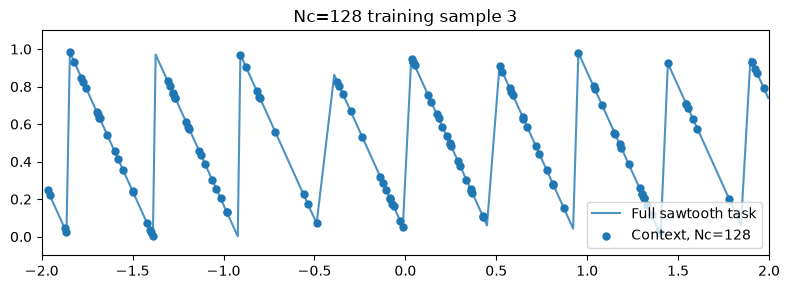

In [4]:
for i in range(4):
    x = batch.x[i, :, 0].cpu()
    y = batch.y[i, :, 0].cpu()

    xc = batch.xc[i, :, 0].cpu()
    yc = batch.yc[i, :, 0].cpu()

    order = x.argsort()

    plt.figure(figsize=(8, 3))
    plt.plot(
        x[order],
        y[order],
        alpha=0.8,
        label="Full sawtooth task",
    )
    plt.scatter(
        xc,
        yc,
        s=25,
        label=f"Context, Nc={len(xc)}",
        zorder=3,
    )

    plt.title(f"Nc=128 training sample {i}")
    plt.xlim(-2.0, 2.0)
    plt.ylim(-0.1, 1.1)
    plt.legend()
    plt.tight_layout()
    plt.show()